# 2D Flow Over a Cylinder — Finite Volume Method

## Problem Description

We simulate **incompressible viscous flow past a circular cylinder** in 2D using the **Finite Volume Method (FVM)** on a Cartesian grid with an immersed boundary approach for the cylinder.

```
  Inlet (U∞)                                 Outlet
  ──────→    ┌─────────────────────────────┐
  ──────→    │                             │
  ──────→    │         ●  (cylinder)       │ → → →
  ──────→    │                             │
  ──────→    └─────────────────────────────┘
             No-slip top & bottom (or free-slip)
```

### Governing Equations

**Continuity (mass conservation):**
$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

**x-Momentum:**
$$\frac{\partial u}{\partial t} + \frac{\partial (uu)}{\partial x} + \frac{\partial (vu)}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

**y-Momentum:**
$$\frac{\partial v}{\partial t} + \frac{\partial (uv)}{\partial x} + \frac{\partial (vv)}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)$$

### Finite Volume Discretization

We integrate the governing equations over each **control volume** (cell). For a cell $(i,j)$ with area $\Delta x \cdot \Delta y$:

$$\oint_{\partial \Omega} \mathbf{F} \cdot \hat{n} \, dS = \sum_{\text{faces}} F_{\text{face}} \cdot A_{\text{face}}$$

where the fluxes through East, West, North, South faces are computed using central differences for diffusion and upwind/central for convection.

### Parameters

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Free-stream velocity | $U_\infty$ | 1.0 m/s |
| Cylinder diameter | $D$ | 0.2 m |
| Kinematic viscosity | $\nu$ | 0.01 m²/s |
| Reynolds number | $Re = U_\infty D / \nu$ | 20 |

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle
import matplotlib.colors as mcolors

## 2. Simulation Parameters

In [2]:
# Domain dimensions
Lx = 2.2                 # Domain length (m)
Ly = 0.8                 # Domain height (m)

# Grid resolution
Nx = 220                 # Cells in x-direction
Ny = 80                  # Cells in y-direction
dx = Lx / Nx
dy = Ly / Ny

# Cylinder parameters
cx, cy = 0.5, 0.4       # Cylinder center
R = 0.1                  # Cylinder radius (D = 0.2)
D = 2 * R               # Diameter

# Physical parameters
rho = 1.0                # Density (kg/m³)
U_inf = 1.0              # Free-stream velocity (m/s)
nu = U_inf * D / 20      # Kinematic viscosity → Re = 20
Re = U_inf * D / nu

# Time-stepping
dt = 0.0005              # Time step (s)
nt = 10000               # Number of time steps

# Pressure solver
nit = 80                 # Pressure Poisson iterations

print(f"Domain: {Lx} x {Ly} m")
print(f"Grid: {Nx} x {Ny} cells")
print(f"dx = {dx:.5f}, dy = {dy:.5f}")
print(f"Cylinder: center=({cx}, {cy}), D={D}")
print(f"Re = {Re:.0f}, nu = {nu:.4f}")
print(f"dt = {dt}, Total time = {nt*dt:.2f} s")

# CFL check
CFL = U_inf * dt / dx
diff_stability = nu * dt / dx**2
print(f"CFL = {CFL:.3f}, Diffusion number = {diff_stability:.3f}")

Domain: 2.2 x 0.8 m
Grid: 220 x 80 cells
dx = 0.01000, dy = 0.01000
Cylinder: center=(0.5, 0.4), D=0.2
Re = 20, nu = 0.0100
dt = 0.0005, Total time = 5.00 s
CFL = 0.050, Diffusion number = 0.050


## 3. Create Grid and Cylinder Mask

We use a **collocated Cartesian grid** with a boolean mask to represent the cylinder as an immersed boundary.

- `mask[j, i] = True` → **Fluid** cell
- `mask[j, i] = False` → **Solid** (inside cylinder)

<>:26: SyntaxWarning: invalid escape sequence '\i'
<>:26: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2229625/891446387.py:26: SyntaxWarning: invalid escape sequence '\i'
  ax.annotate('Inlet\n$U_\infty$', xy=(0.02, Ly/2), fontsize=11, color='green',


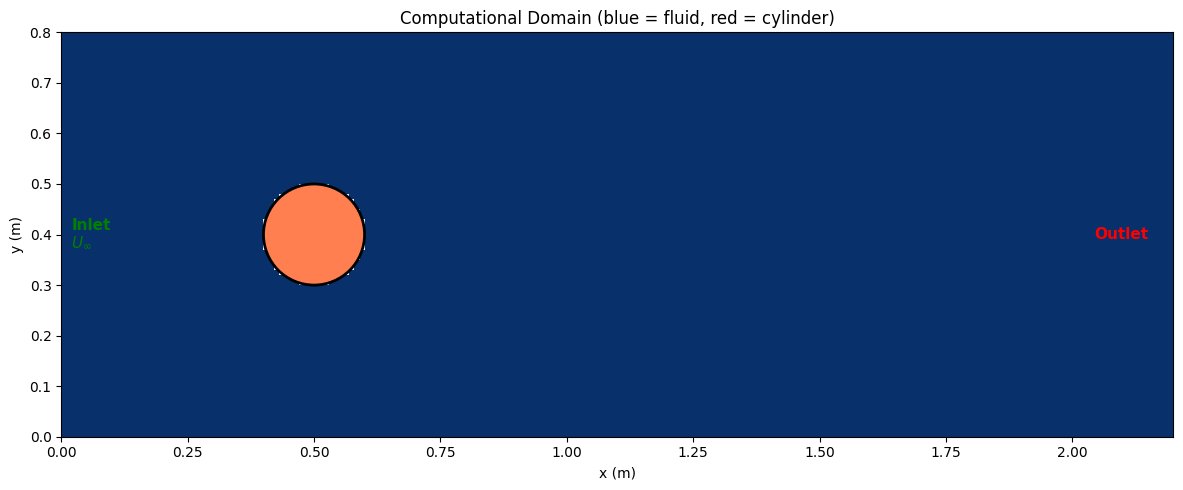

Fluid cells: 17284 / 17600
Solid cells: 316 / 17600


In [3]:
# Cell-center coordinates
x = np.linspace(dx/2, Lx - dx/2, Nx)
y = np.linspace(dy/2, Ly - dy/2, Ny)
X, Y = np.meshgrid(x, y)

# For plotting (cell edges)
xe = np.linspace(0, Lx, Nx + 1)
ye = np.linspace(0, Ly, Ny + 1)
Xe, Ye = np.meshgrid(xe, ye)

# Cylinder mask: True = fluid, False = solid
dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
mask = dist > R

# Visualize the domain and grid
fig, ax = plt.subplots(figsize=(14, 5))
ax.pcolormesh(Xe, Ye, mask.astype(float), cmap='Blues', shading='flat')
circle = Circle((cx, cy), R, fill=True, facecolor='coral', edgecolor='black', linewidth=2)
ax.add_patch(circle)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Computational Domain (blue = fluid, red = cylinder)')
ax.set_aspect('equal')

# Mark inlet/outlet
ax.annotate('Inlet\n$U_\infty$', xy=(0.02, Ly/2), fontsize=11, color='green',
            ha='left', va='center', fontweight='bold')
ax.annotate('Outlet', xy=(Lx-0.05, Ly/2), fontsize=11, color='red',
            ha='right', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Fluid cells: {mask.sum()} / {Nx*Ny}")
print(f"Solid cells: {(~mask).sum()} / {Nx*Ny}")

## 4. Initialize Fields

In [4]:
# Velocity fields — initialize with free-stream
u = np.ones((Ny, Nx)) * U_inf   # x-velocity
v = np.zeros((Ny, Nx))           # y-velocity
p = np.zeros((Ny, Nx))           # pressure

# Zero velocity inside the cylinder
u[~mask] = 0.0
v[~mask] = 0.0

## 5. Boundary Condition Functions

| Boundary | Condition |
|----------|----------|
| **Inlet** (left) | $u = U_\infty$, $v = 0$ |
| **Outlet** (right) | Zero-gradient (convective outflow) |
| **Top/Bottom** | Free-slip ($\partial u/\partial y = 0$, $v = 0$) |
| **Cylinder** | No-slip ($u = 0$, $v = 0$) |

In [5]:
def apply_bc(u, v, p, mask, U_inf):
    """Apply boundary conditions for flow over cylinder."""
    # Inlet (left wall): uniform inflow
    u[:, 0] = U_inf
    v[:, 0] = 0.0

    # Outlet (right wall): zero-gradient (Neumann)
    u[:, -1] = u[:, -2]
    v[:, -1] = v[:, -2]

    # Top wall: free-slip
    u[-1, :] = u[-2, :]
    v[-1, :] = 0.0

    # Bottom wall: free-slip
    u[0, :] = u[1, :]
    v[0, :] = 0.0

    # Cylinder: no-slip (immersed boundary)
    u[~mask] = 0.0
    v[~mask] = 0.0

    # Pressure BCs
    p[:, 0] = p[:, 1]     # Inlet: Neumann
    p[:, -1] = 0.0        # Outlet: reference pressure = 0
    p[0, :] = p[1, :]     # Bottom: Neumann
    p[-1, :] = p[-2, :]   # Top: Neumann
    p[~mask] = 0.0        # Cylinder interior

    return u, v, p

## 6. Finite Volume Solver

### Pressure Poisson Equation

After computing the intermediate velocity $(u^*, v^*)$, we solve the pressure Poisson equation:

$$\frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = \frac{\rho}{\Delta t}\left(\frac{\partial u^*}{\partial x} + \frac{\partial v^*}{\partial y}\right)$$

using Jacobi iteration. The FVM discretization gives:

$$p_{i,j} = \frac{(p_{i+1,j} + p_{i-1,j})\Delta y^2 + (p_{i,j+1} + p_{i,j-1})\Delta x^2 - b_{i,j}\Delta x^2\Delta y^2}{2(\Delta x^2 + \Delta y^2)}$$

In [6]:
def pressure_poisson_fvm(p, u, v, dx, dy, dt, rho, nit, mask):
    """Solve pressure Poisson equation using FVM (Jacobi iteration)."""
    # RHS: divergence of intermediate velocity field
    b = np.zeros_like(p)
    b[1:-1, 1:-1] = (rho / dt) * (
        (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
        (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
    )
    b[~mask] = 0.0

    coeff = 2 * (dx**2 + dy**2)

    for _ in range(nit):
        pn = p.copy()

        p[1:-1, 1:-1] = (
            (pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 +
            (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2 -
            b[1:-1, 1:-1] * dx**2 * dy**2
        ) / coeff

        # Solid cells: zero pressure
        p[~mask] = 0.0

        # Pressure BCs
        p[:, 0] = p[:, 1]       # Inlet: Neumann
        p[:, -1] = 0.0          # Outlet: Dirichlet (reference)
        p[0, :] = p[1, :]       # Bottom: Neumann
        p[-1, :] = p[-2, :]     # Top: Neumann

    return p

### Main FVM Time-Stepping Loop

**Fractional Step (Chorin's Projection) Method:**

1. **Predictor**: Compute intermediate velocity from convective + diffusive fluxes through CV faces
2. **Pressure solve**: Solve the Poisson equation to enforce the continuity constraint
3. **Corrector**: Update velocity using the pressure gradient
4. **Apply BCs**: Enforce inlet, outlet, wall, and cylinder conditions

In [7]:
def compute_fluxes_fvm(u, v, dx, dy, nu, mask):
    """
    Compute convective and diffusive fluxes through control volume faces.
    Returns the net flux (RHS) for u and v momentum equations.
    """
    Ny, Nx = u.shape

    # --- Convective fluxes (central differencing) ---
    # du(uu)/dx: flux of u-momentum through east/west faces
    u_conv_x = u[1:-1, 1:-1] * (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx)
    # du(vu)/dy: flux of u-momentum through north/south faces
    u_conv_y = v[1:-1, 1:-1] * (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy)

    # dv(uv)/dx
    v_conv_x = u[1:-1, 1:-1] * (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx)
    # dv(vv)/dy
    v_conv_y = v[1:-1, 1:-1] * (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)

    # --- Diffusive fluxes (central differencing of gradients) ---
    u_diff = nu * (
        (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2 +
        (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
    )
    v_diff = nu * (
        (v[1:-1, 2:] - 2*v[1:-1, 1:-1] + v[1:-1, :-2]) / dx**2 +
        (v[2:, 1:-1] - 2*v[1:-1, 1:-1] + v[:-2, 1:-1]) / dy**2
    )

    # Net flux = -convection + diffusion
    Fu = -u_conv_x - u_conv_y + u_diff
    Fv = -v_conv_x - v_conv_y + v_diff

    return Fu, Fv


def compute_forces(p, u, v, dx, dy, nu, rho, mask, cx, cy, R):
    """
    Estimate drag and lift on the cylinder from pressure
    and viscous stress at cells adjacent to the solid boundary.
    """
    Ny, Nx = p.shape
    Fx = 0.0  # Drag (x-direction)
    Fy = 0.0  # Lift (y-direction)

    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):
            if not mask[j, i]:  # Solid cell
                # Check each neighbor — if it's fluid, there's a boundary face
                # East face
                if i < Nx - 1 and mask[j, i + 1]:
                    Fx -= p[j, i + 1] * dy
                    Fx -= rho * nu * (u[j, i + 1] - u[j, i]) / dx * dy
                # West face
                if i > 0 and mask[j, i - 1]:
                    Fx += p[j, i - 1] * dy
                    Fx += rho * nu * (u[j, i] - u[j, i - 1]) / dx * dy
                # North face
                if j < Ny - 1 and mask[j + 1, i]:
                    Fy -= p[j + 1, i] * dx
                    Fy -= rho * nu * (v[j + 1, i] - v[j, i]) / dy * dx
                # South face
                if j > 0 and mask[j - 1, i]:
                    Fy += p[j - 1, i] * dx
                    Fy += rho * nu * (v[j, i] - v[j - 1, i]) / dy * dx

    return Fx, Fy


def flow_over_cylinder(u, v, p, dx, dy, dt, rho, nu, nit, nt, mask, U_inf, cx, cy, R):
    """Run flow over cylinder simulation using FVM."""
    interior_mask = mask[1:-1, 1:-1]

    # Storage for drag/lift history
    drag_hist = []
    lift_hist = []
    time_hist = []

    for n in range(nt):
        un = u.copy()
        vn = v.copy()

        # --- Step 1: Compute fluxes through CV faces ---
        Fu, Fv = compute_fluxes_fvm(un, vn, dx, dy, nu, mask)

        # Update intermediate velocity (only in fluid cells)
        u[1:-1, 1:-1] = np.where(interior_mask,
                                  un[1:-1, 1:-1] + dt * Fu,
                                  0.0)
        v[1:-1, 1:-1] = np.where(interior_mask,
                                  vn[1:-1, 1:-1] + dt * Fv,
                                  0.0)

        # --- Step 2: Solve pressure Poisson equation ---
        p = pressure_poisson_fvm(p, u, v, dx, dy, dt, rho, nit, mask)

        # --- Step 3: Velocity correction ---
        dp_dx = (p[1:-1, 2:] - p[1:-1, :-2]) / (2 * dx)
        dp_dy = (p[2:, 1:-1] - p[:-2, 1:-1]) / (2 * dy)

        u[1:-1, 1:-1] = np.where(interior_mask,
                                  u[1:-1, 1:-1] - dt / rho * dp_dx,
                                  0.0)
        v[1:-1, 1:-1] = np.where(interior_mask,
                                  v[1:-1, 1:-1] - dt / rho * dp_dy,
                                  0.0)

        # --- Step 4: Apply boundary conditions ---
        u, v, p = apply_bc(u, v, p, mask, U_inf)

        # --- Compute drag & lift (pressure-based estimate) ---
        if (n + 1) % 50 == 0:
            Fd, Fl = compute_forces(p, u, v, dx, dy, nu, rho, mask, cx, cy, R)
            drag_hist.append(Fd)
            lift_hist.append(Fl)
            time_hist.append((n + 1) * dt)

        # Print progress
        if (n + 1) % 2000 == 0:
            div_field = np.abs(
                (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
                (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
            )
            div_field[~interior_mask] = 0.0
            max_div = np.max(div_field)
            max_u = np.max(np.abs(u[mask]))
            print(f"Step {n+1}/{nt} | Max div: {max_div:.2e} | Max |u|: {max_u:.3f}")

    return u, v, p, np.array(time_hist), np.array(drag_hist), np.array(lift_hist)

## 7. Run the Simulation

In [8]:
u, v, p, time_hist, drag_hist, lift_hist = flow_over_cylinder(
    u, v, p, dx, dy, dt, rho, nu, nit, nt, mask, U_inf, cx, cy, R
)
print("\nSimulation complete!")

Step 2000/10000 | Max div: 9.80e+00 | Max |u|: 1.545
Step 4000/10000 | Max div: 9.83e+00 | Max |u|: 1.548
Step 6000/10000 | Max div: 9.95e+00 | Max |u|: 1.542
Step 8000/10000 | Max div: 9.96e+00 | Max |u|: 1.541
Step 10000/10000 | Max div: 9.96e+00 | Max |u|: 1.541

Simulation complete!


## 8. Results Visualization

### 8.1 Velocity Magnitude

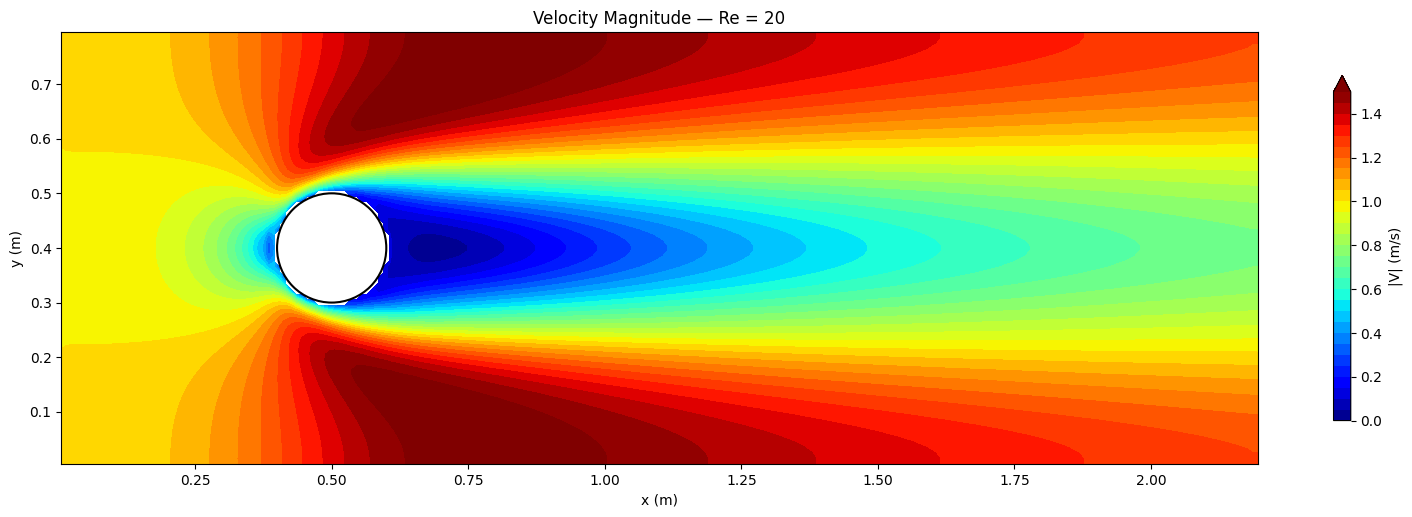

In [9]:
speed = np.sqrt(u**2 + v**2)
speed_plot = np.ma.array(speed, mask=~mask)

fig, ax = plt.subplots(figsize=(16, 5))
cf = ax.contourf(X, Y, speed_plot, levels=np.linspace(0, 1.5, 31), cmap=cm.jet, extend='max')
plt.colorbar(cf, ax=ax, label='|V| (m/s)', shrink=0.8)
circle = Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)
ax.set_title(f'Velocity Magnitude — Re = {Re:.0f}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 8.2 Streamlines

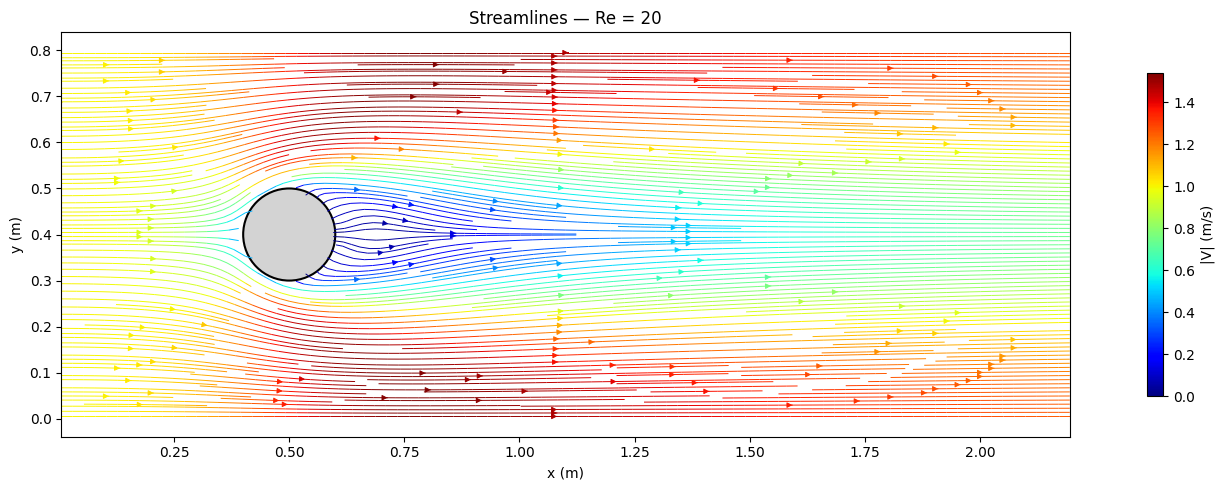

In [10]:
u_stream = u.copy()
v_stream = v.copy()
u_stream[~mask] = 0.0
v_stream[~mask] = 0.0

fig, ax = plt.subplots(figsize=(16, 5))
speed_s = np.sqrt(u_stream**2 + v_stream**2)
strm = ax.streamplot(x, y, u_stream, v_stream, density=3, linewidth=0.7,
                     color=speed_s, cmap=cm.jet, arrowsize=0.8)
plt.colorbar(strm.lines, ax=ax, label='|V| (m/s)', shrink=0.8)
circle = Circle((cx, cy), R, fill=True, facecolor='lightgray', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)
ax.set_title(f'Streamlines — Re = {Re:.0f}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 8.3 Velocity Vectors (Quiver Plot)

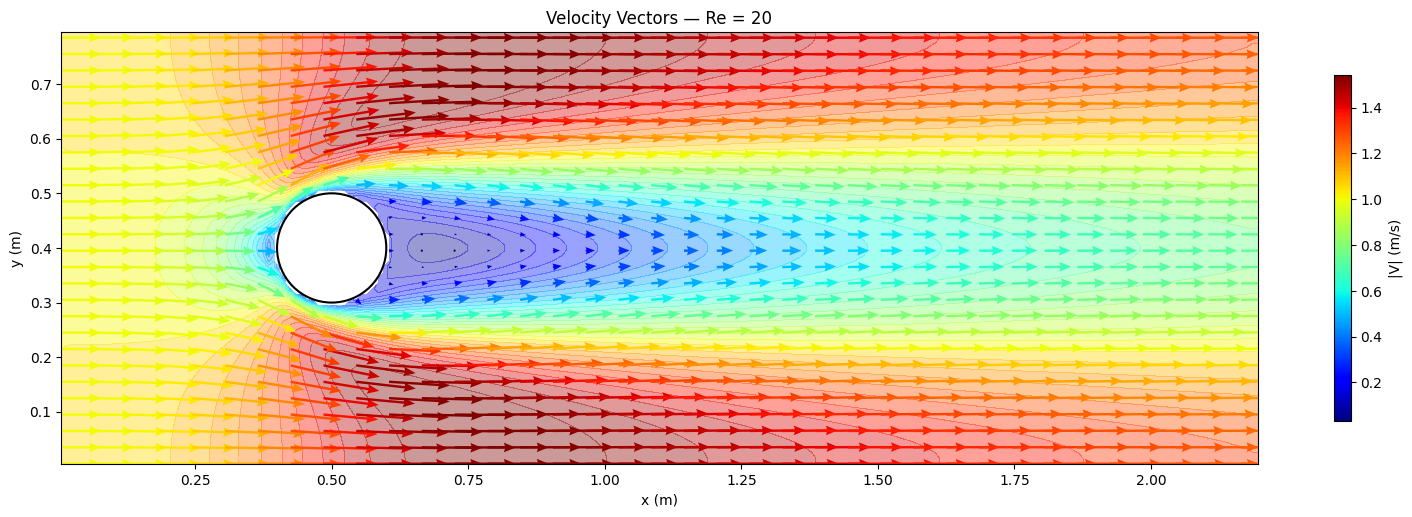

In [11]:
# Prepare velocity vectors (zero out solid)
u_vec = u.copy()
v_vec = v.copy()
u_vec[~mask] = np.nan
v_vec[~mask] = np.nan
speed_vec = np.sqrt(np.nan_to_num(u_vec)**2 + np.nan_to_num(v_vec)**2)

# Subsample for clean arrows
skip_x = 6
skip_y = 3

fig, ax = plt.subplots(figsize=(16, 5))

# Background: velocity magnitude contour
cf = ax.contourf(X, Y, np.ma.array(speed, mask=~mask),
                 levels=np.linspace(0, 1.5, 31), cmap=cm.jet, extend='max', alpha=0.4)

# Quiver (velocity vectors)
Q = ax.quiver(X[::skip_y, ::skip_x], Y[::skip_y, ::skip_x],
              u_vec[::skip_y, ::skip_x], v_vec[::skip_y, ::skip_x],
              speed_vec[::skip_y, ::skip_x],
              cmap=cm.jet, scale=30, width=0.002, headwidth=4, headlength=5)
plt.colorbar(Q, ax=ax, label='|V| (m/s)', shrink=0.8)

# Cylinder
circle = Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5, zorder=5)
ax.add_patch(circle)

ax.set_title(f'Velocity Vectors — Re = {Re:.0f}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 8.4 Pressure Field

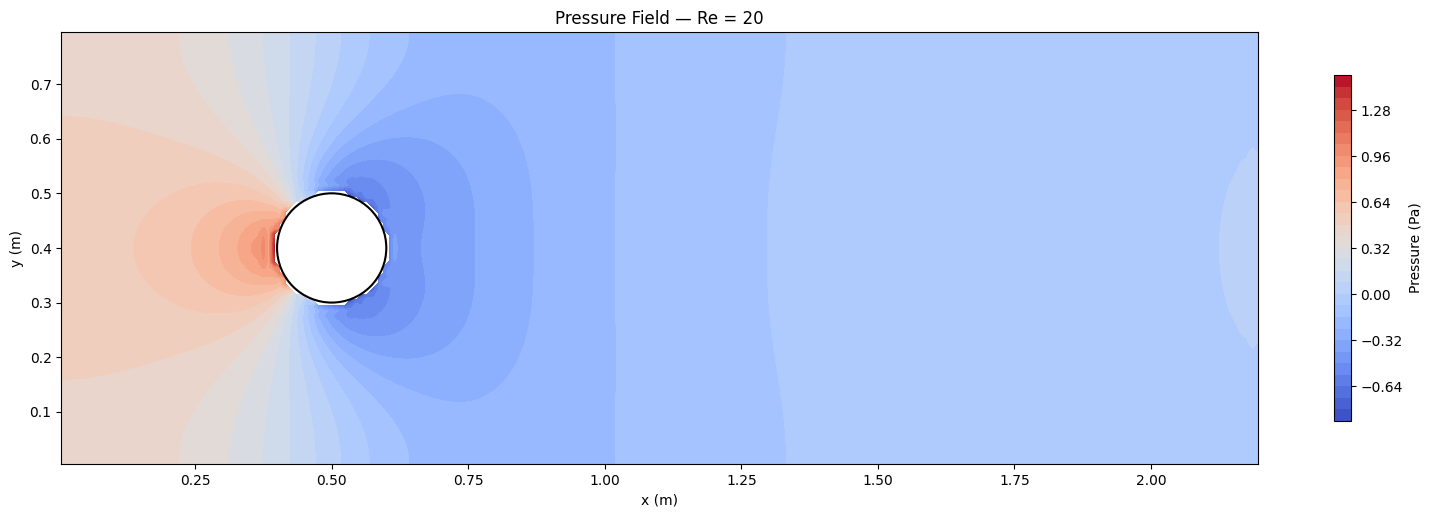

In [12]:
p_plot = np.ma.array(p, mask=~mask)

fig, ax = plt.subplots(figsize=(16, 5))
cf = ax.contourf(X, Y, p_plot, levels=30, cmap=cm.coolwarm)
plt.colorbar(cf, ax=ax, label='Pressure (Pa)', shrink=0.8)
circle = Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)
ax.set_title(f'Pressure Field — Re = {Re:.0f}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 8.5 Vorticity Field

$$\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$

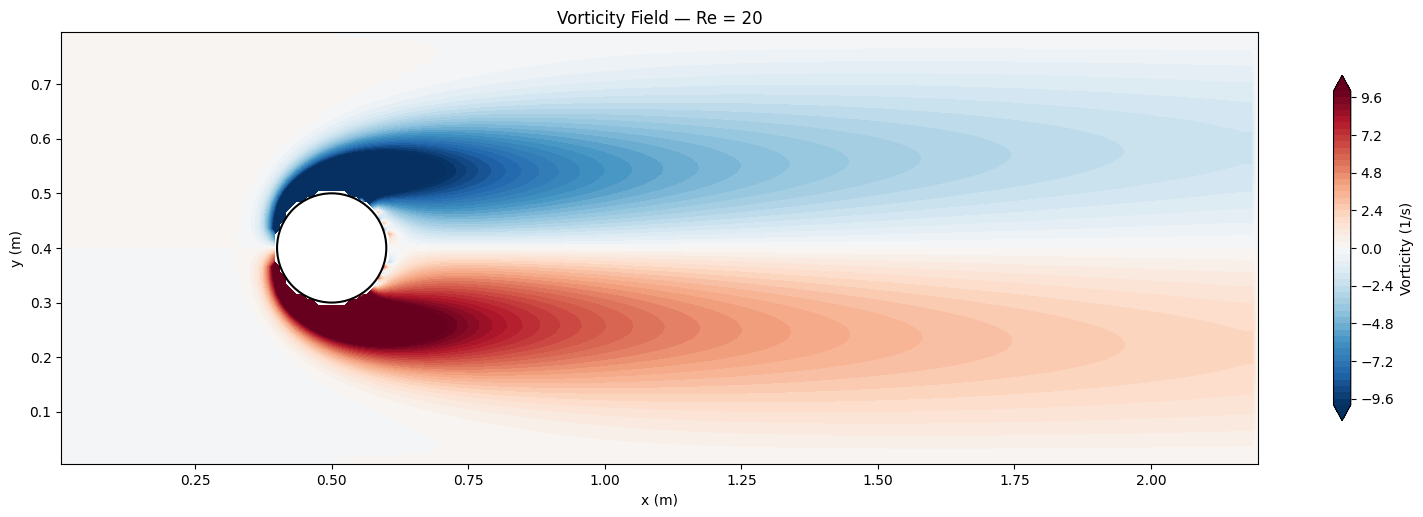

In [13]:
# Compute vorticity
omega = np.zeros_like(u)
omega[1:-1, 1:-1] = (
    (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx) -
    (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy)
)
omega_plot = np.ma.array(omega, mask=~mask)

fig, ax = plt.subplots(figsize=(16, 5))
levels = np.linspace(-10, 10, 51)
cf = ax.contourf(X, Y, omega_plot, levels=levels, cmap=cm.RdBu_r, extend='both')
plt.colorbar(cf, ax=ax, label='Vorticity (1/s)', shrink=0.8)
circle = Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)
ax.set_title(f'Vorticity Field — Re = {Re:.0f}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 8.6 Pressure Coefficient on Cylinder Surface

$$C_p = \frac{p - p_\infty}{\frac{1}{2}\rho U_\infty^2}$$

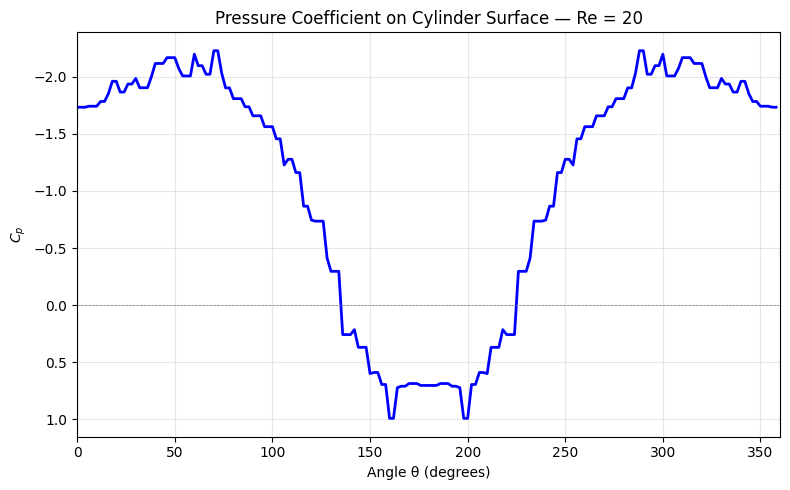

In [14]:
# Sample pressure around the cylinder
n_theta = 180
theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
r_sample = R + 1.5 * max(dx, dy)  # Sample just outside the cylinder

x_sample = cx + r_sample * np.cos(theta)
y_sample = cy + r_sample * np.sin(theta)

# Interpolate pressure (nearest neighbor)
p_surface = np.zeros(n_theta)
for k in range(n_theta):
    ix = np.argmin(np.abs(x - x_sample[k]))
    iy = np.argmin(np.abs(y - y_sample[k]))
    p_surface[k] = p[iy, ix]

# Reference pressure (far upstream)
p_inf = np.mean(p[:, 0])
Cp = (p_surface - p_inf) / (0.5 * rho * U_inf**2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.degrees(theta), Cp, 'b-', linewidth=2)
ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('$C_p$')
ax.set_title(f'Pressure Coefficient on Cylinder Surface — Re = {Re:.0f}')
ax.set_xlim(0, 360)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Convention: Cp increases downward
plt.tight_layout()
plt.show()

### 8.7 Drag and Lift History

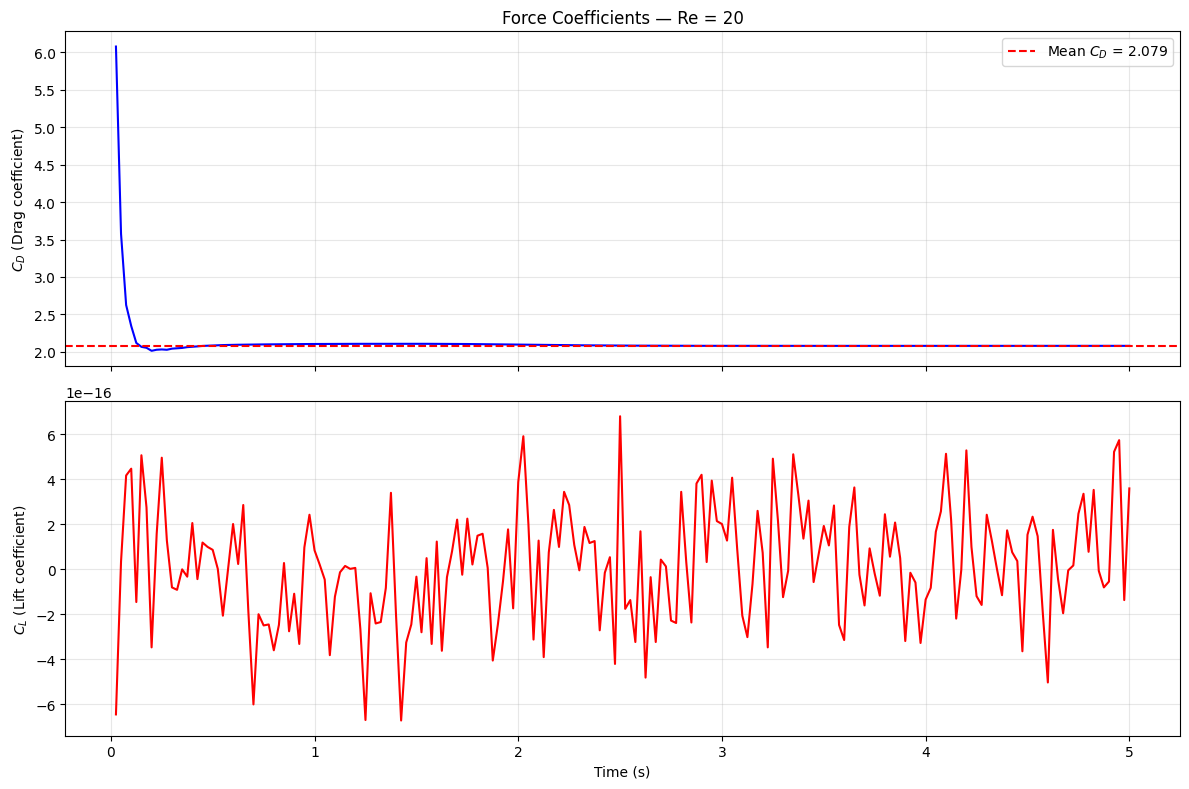

Final Cd ≈ 2.079
Final Cl ≈ 0.0000


In [15]:
if len(time_hist) > 0:
    # Compute drag and lift coefficients
    D_diam = 2 * R
    Cd = drag_hist / (0.5 * rho * U_inf**2 * D_diam)
    Cl = lift_hist / (0.5 * rho * U_inf**2 * D_diam)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(time_hist, Cd, 'b-', linewidth=1.5)
    axes[0].set_ylabel('$C_D$ (Drag coefficient)')
    axes[0].set_title(f'Force Coefficients — Re = {Re:.0f}')
    axes[0].grid(True, alpha=0.3)
    if len(Cd) > 10:
        axes[0].axhline(y=np.mean(Cd[-len(Cd)//4:]), color='red',
                        linestyle='--', label=f'Mean $C_D$ = {np.mean(Cd[-len(Cd)//4:]):.3f}')
        axes[0].legend()

    axes[1].plot(time_hist, Cl, 'r-', linewidth=1.5)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('$C_L$ (Lift coefficient)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final Cd ≈ {np.mean(Cd[-len(Cd)//4:]):.3f}")
    print(f"Final Cl ≈ {np.mean(Cl[-len(Cl)//4:]):.4f}")
else:
    print("No force data recorded.")

### 8.8 Wake Velocity Profiles

<>:14: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\i'
<>:14: SyntaxWarning: invalid escape sequence '\i'
<>:15: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2229625/81072719.py:14: SyntaxWarning: invalid escape sequence '\i'
  ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.5, label='$U_\infty$')
/tmp/ipykernel_2229625/81072719.py:15: SyntaxWarning: invalid escape sequence '\i'
  ax.set_xlabel('$u / U_\infty$')


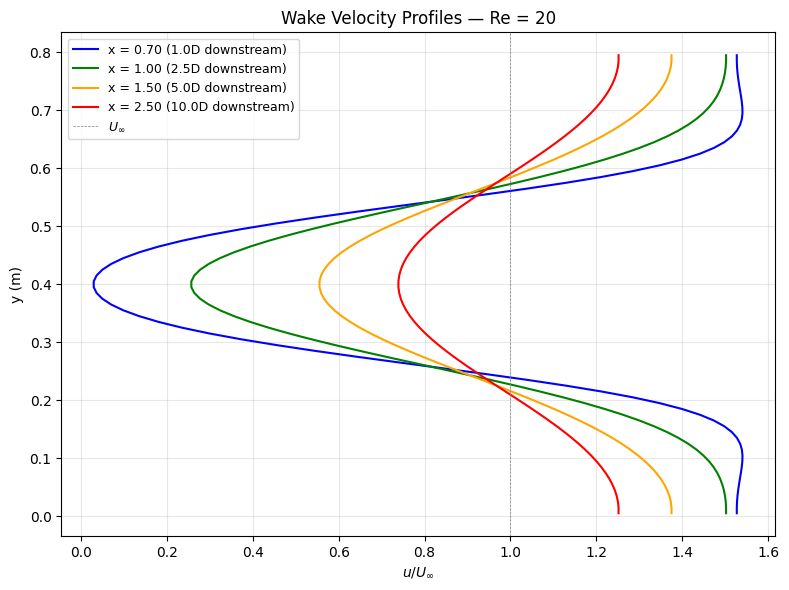

In [16]:
# Downstream locations (distances behind cylinder center)
x_stations = [cx + 2*R, cx + 5*R, cx + 10*R, cx + 20*R]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['blue', 'green', 'orange', 'red']

for k, xs in enumerate(x_stations):
    ix = np.argmin(np.abs(x - xs))
    u_profile = u[:, ix].copy()
    u_profile[~mask[:, ix]] = np.nan
    label = f'x = {xs:.2f} ({(xs-cx)/D:.1f}D downstream)'
    ax.plot(u_profile / U_inf, y, color=colors[k], linewidth=1.5, label=label)

ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.5, label='$U_\infty$')
ax.set_xlabel('$u / U_\infty$')
ax.set_ylabel('y (m)')
ax.set_title(f'Wake Velocity Profiles — Re = {Re:.0f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.9 Zoomed View Near Cylinder

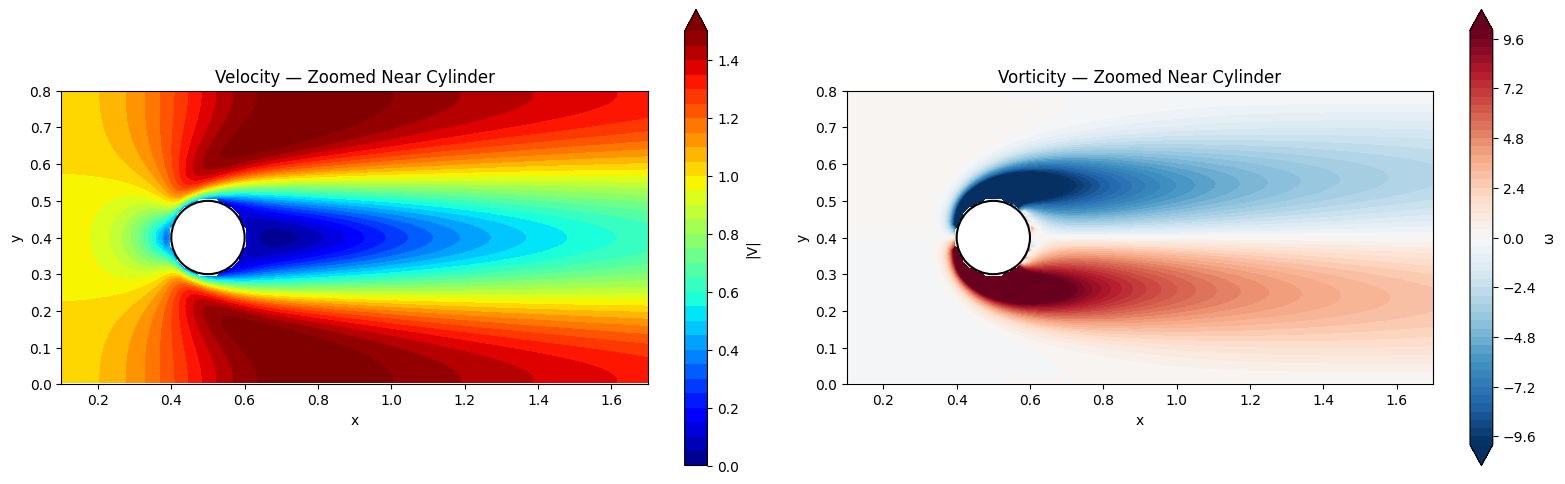

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

zoom = 0.4  # Half-width of zoom window
xlim = (cx - zoom, cx + 3 * zoom)
ylim = (cy - zoom, cy + zoom)

# Velocity magnitude (zoomed)
ax1 = axes[0]
cf = ax1.contourf(X, Y, speed_plot, levels=np.linspace(0, 1.5, 31), cmap=cm.jet, extend='max')
plt.colorbar(cf, ax=ax1, label='|V|', shrink=0.8)
ax1.add_patch(Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5))
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_title('Velocity — Zoomed Near Cylinder')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')

# Vorticity (zoomed)
ax2 = axes[1]
cf2 = ax2.contourf(X, Y, omega_plot, levels=np.linspace(-10, 10, 51), cmap=cm.RdBu_r, extend='both')
plt.colorbar(cf2, ax=ax2, label='ω', shrink=0.8)
ax2.add_patch(Circle((cx, cy), R, fill=True, facecolor='white', edgecolor='black', linewidth=1.5))
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_title('Vorticity — Zoomed Near Cylinder')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## 9. Summary

| Parameter | Value |
|-----------|-------|
| Domain | 2.2 × 0.8 m |
| Grid | 220 × 80 cells |
| Cylinder | D = 0.2 m, center at (0.5, 0.4) |
| Reynolds number | 20 |
| Method | Finite Volume (Chorin's projection) |
| Cylinder treatment | Immersed boundary (boolean mask) |
| Convection | Central differences |
| Diffusion | Second-order central |
| Time integration | Explicit Euler |
| Pressure solver | Jacobi iteration |

### Key Observations

1. At **Re = 20**, the flow remains **steady and symmetric** — a pair of recirculation bubbles forms behind the cylinder
2. **High pressure** at the front stagnation point, **low pressure** at the sides
3. The **wake deficit** (reduced u-velocity) is visible downstream and gradually recovers
4. The **drag coefficient** $C_D$ converges to a steady value

### Flow Regimes (for reference)

| Re Range | Flow Behavior |
|----------|---------------|
| Re < 5 | Creeping flow, no separation |
| 5 < Re < 47 | Steady separated flow (twin vortices) |
| 47 < Re < 190 | Vortex shedding (von Kármán street) |
| Re > 190 | Turbulent wake |

### Possible Extensions

- Increase **Re to 100–200** to observe **vortex shedding** (von Kármán vortex street)
- Use **upwind differencing** for convection at higher Re for numerical stability
- Implement **SOR** (Successive Over-Relaxation) for faster pressure convergence
- Compute **Strouhal number** $St = fD/U_\infty$ from lift oscillation frequency